In [1]:
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"

In [2]:
# ==========================
# 1. IMPORTS
# ==========================
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from glob import glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns

2026-02-21 09:22:58.029227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771665778.215403      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771665778.283678      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771665778.717490      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771665778.717543      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771665778.717546      55 computation_placer.cc:177] computation placer alr

In [3]:
# ==========================
# 2. REPRODUCIBILITY
# ==========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# ==========================
# 3. GPU DETECTION (SAFE VERSION)
# ==========================
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"{len(gpus)} GPU(s) detected and memory growth enabled.")
    except RuntimeError as e:
        print(e)
else:
    print("Running on CPU")


1 GPU(s) detected and memory growth enabled.


In [5]:
import os

data_path = "/kaggle/input/datasets/ambarish/breakhis"
print(os.listdir(data_path))

['BreaKHis_v1', 'Folds.csv']


In [6]:
# ==========================
# 4. DATASET PATH (KAGGLE)
# ==========================

SRC_ROOT = "/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
WORK_ROOT = "/kaggle/working/breakhis_processed"

MAG = "200X"   # choose 40X / 100X / 200X / 400X

CLASSES = [
    "adenosis", "fibroadenoma", "tubular_adenoma", "phyllodes_tumor",
    "ductal_carcinoma", "lobular_carcinoma",
    "mucinous_carcinoma", "papillary_carcinoma"
]

In [7]:
# ==========================
# 5. COPY SELECTED MAGNIFICATION
# ==========================
if not os.path.exists(WORK_ROOT):
    os.makedirs(WORK_ROOT)

for cls in CLASSES:
    os.makedirs(os.path.join(WORK_ROOT, cls), exist_ok=True)

for label in ["benign", "malignant"]:
    for cls in CLASSES:
        class_root = os.path.join(SRC_ROOT, label, "SOB", cls)
        if not os.path.exists(class_root):
            continue

        for patient in os.listdir(class_root):
            patient_dir = os.path.join(class_root, patient)
            mag_dir = os.path.join(patient_dir, MAG)
            if not os.path.exists(mag_dir):
                continue

            for fname in os.listdir(mag_dir):
                src_f = os.path.join(mag_dir, fname)
                dst_f = os.path.join(WORK_ROOT, cls, f"{patient}_{fname}")
                shutil.copy(src_f, dst_f)

print("Dataset prepared.")

Dataset prepared.


In [8]:
# ==========================
# 6. LOAD IMAGE PATHS
# ==========================
IMG_SIZE = 224
image_paths = []
labels = []

for idx, cls in enumerate(CLASSES):
    files = glob(os.path.join(WORK_ROOT, cls, "*.png"))
    image_paths.extend(files)
    labels.extend([idx] * len(files))

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total Images:", len(image_paths))

Total Images: 2013


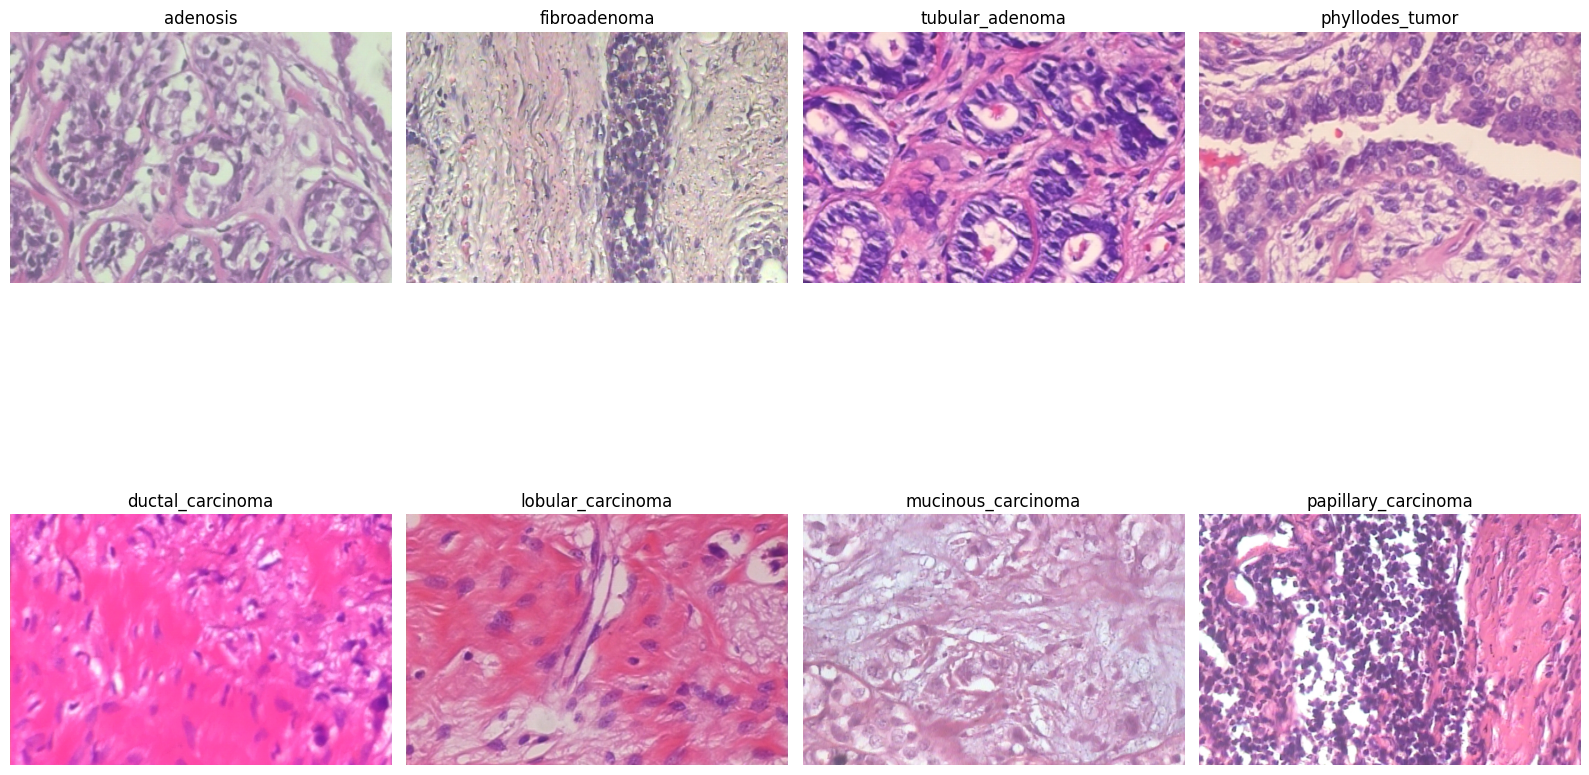

In [9]:
# ==========================
# 7. VISUALIZE RANDOM SAMPLE FROM EACH SUBCLASS
# ==========================

import random

num_classes = len(CLASSES)

plt.figure(figsize=(16, 12))

for class_idx in range(num_classes):
    # Get indices belonging to this class
    class_indices = np.where(labels == class_idx)[0]
    
    # Randomly select one image from this class
    random_idx = random.choice(class_indices)
    
    img = plt.imread(image_paths[random_idx])
    
    plt.subplot(2, 4, class_idx + 1)
    plt.imshow(img)
    plt.title(CLASSES[class_idx])
    plt.axis("off")

#plt.suptitle("Random Sample From Each BreakHis Subclass", fontsize=16)
plt.tight_layout()
plt.show()


In [10]:
# ==========================
# 8. TRAIN / VALIDATION SPLIT
# ==========================
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(image_paths, labels))

train_paths, val_paths = image_paths[train_idx], image_paths[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]

print("Train size:", len(train_paths))
print("Validation size:", len(val_paths))

Train size: 1610
Validation size: 403


In [11]:
# ==========================
# 9. DATA PIPELINE
# ==========================
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess_input(img)
    return img, label

BATCH_SIZE = 16

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1771665855.328216      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
# ==========================================================
# 10. SIMCLR AUGMENTATION (XLA SAFE VERSION)
# ==========================================================

@tf.function
def augment(images):
    images = tf.image.random_flip_left_right(images)
    images = tf.image.random_brightness(images, max_delta=0.2)
    images = tf.image.random_contrast(images, lower=0.8, upper=1.2)
    images = tf.image.random_saturation(images, lower=0.8, upper=1.2)
    images = tf.image.random_crop(images, size=[tf.shape(images)[0], IMG_SIZE, IMG_SIZE, 3])
    return images


In [13]:
# ==========================================================
# 11. SIMCLR MODEL
# ==========================================================
base_encoder = ResNet50(include_top=False, weights="imagenet",
                        input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling="avg")

projection_head = keras.Sequential([
    layers.Dense(256, activation="relu"),
    layers.Dense(128)
])

class SimCLR(keras.Model):
    def __init__(self, encoder, projector, temperature=0.1):
        super().__init__()
        self.encoder = encoder
        self.projector = projector
        self.temperature = temperature

    def compile(self, optimizer):
        super().compile()
        self.optimizer = optimizer
        self.loss_tracker = keras.metrics.Mean(name="contrastive_loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def nt_xent_loss(self, z):
        """
        Proper NT-Xent loss
        z shape: (2N, projection_dim)
        """
        z = tf.math.l2_normalize(z, axis=1)
        similarity_matrix = tf.matmul(z, z, transpose_b=True)

        batch_size = tf.shape(z)[0] // 2
        temperature = self.temperature

        # Mask self similarity
        mask = tf.eye(tf.shape(similarity_matrix)[0])
        similarity_matrix = similarity_matrix / temperature
        similarity_matrix = similarity_matrix - 1e9 * mask

        # Positive pairs
        positives = tf.concat([
            tf.range(batch_size, 2 * batch_size),
            tf.range(0, batch_size)
        ], axis=0)

        loss = tf.keras.losses.sparse_categorical_crossentropy(
            positives,
            similarity_matrix,
            from_logits=True
        )

        return tf.reduce_mean(loss)

    def train_step(self, data):
        images, _ = data

        aug1 = augment(images)
        aug2 = augment(images)


        with tf.GradientTape() as tape:
            h1 = self.encoder(aug1, training=True)
            h2 = self.encoder(aug2, training=True)

            z1 = self.projector(h1)
            z2 = self.projector(h2)

            z = tf.concat([z1, z2], axis=0)
            loss = self.nt_xent_loss(z)

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        return {"contrastive_loss": self.loss_tracker.result()}

  

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [14]:
# ==========================================================
# 12. PRETRAIN
# ==========================================================
simclr = SimCLR(base_encoder, projection_head)
simclr.compile(optimizer=keras.optimizers.Adam(1e-4))

simclr.fit(train_ds, epochs=15)

#base_encoder.save_weights("simclr_pretrained_resnet50.h5")

Epoch 1/15


I0000 00:00:1771665912.974129     127 service.cc:152] XLA service 0x7e79d00034c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771665912.974163     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771665921.025671     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771665949.093455     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


101/101 ━━━━━━━━━━━━━━━━━━━━ 129s 480ms/step - contrastive_loss: 0.1033
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - contrastive_loss: 0.0124
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step - contrastive_loss: 0.0066
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - contrastive_loss: 0.0055
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - contrastive_loss: 0.0047
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - contrastive_loss: 0.0043
Epoch 7/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - contrastive_loss: 0.0046
Epoch 8/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 23s 164ms/step - contrastive_loss: 0.0040
Epoch 9/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - contrastive_loss: 0.0040
Epoch 10/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - contrastive_loss: 0.0034
Epoch 11/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - contrastive_loss: 0.0035
Epoch 12/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 22s 164ms/step - contrastive_loss: 0.0030
Epoch 13/15
101/101 ━━━

In [15]:
base_encoder.save_weights("simclr_pretrained_resnet50.weights.h5")

In [16]:
# ==========================================================
# 13. FINETUNE CLASSIFIER
# ==========================================================
base_encoder.trainable = True

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_encoder(inputs, training=False)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(CLASSES), activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#early_stop = keras.callbacks.EarlyStopping( patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    #callbacks=[early_stop]
)

Epoch 1/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 91s 358ms/step - accuracy: 0.4805 - loss: 1.6424 - val_accuracy: 0.6600 - val_loss: 1.1471
Epoch 2/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.7384 - loss: 0.7037 - val_accuracy: 0.7618 - val_loss: 0.6255
Epoch 3/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.8495 - loss: 0.4219 - val_accuracy: 0.7990 - val_loss: 0.7243
Epoch 4/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.9030 - loss: 0.3088 - val_accuracy: 0.8189 - val_loss: 0.6621
Epoch 5/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.9264 - loss: 0.2206 - val_accuracy: 0.7940 - val_loss: 0.8305
Epoch 6/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.9236 - loss: 0.2151 - val_accuracy: 0.8213 - val_loss: 0.6372
Epoch 7/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.9422 - loss: 0.1698 - val_accuracy: 0.8437 - val_loss: 0.4903
Epoch 8/30
101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.9581 - loss: 0

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step
Final Validation Accuracy: 0.8312655086848635


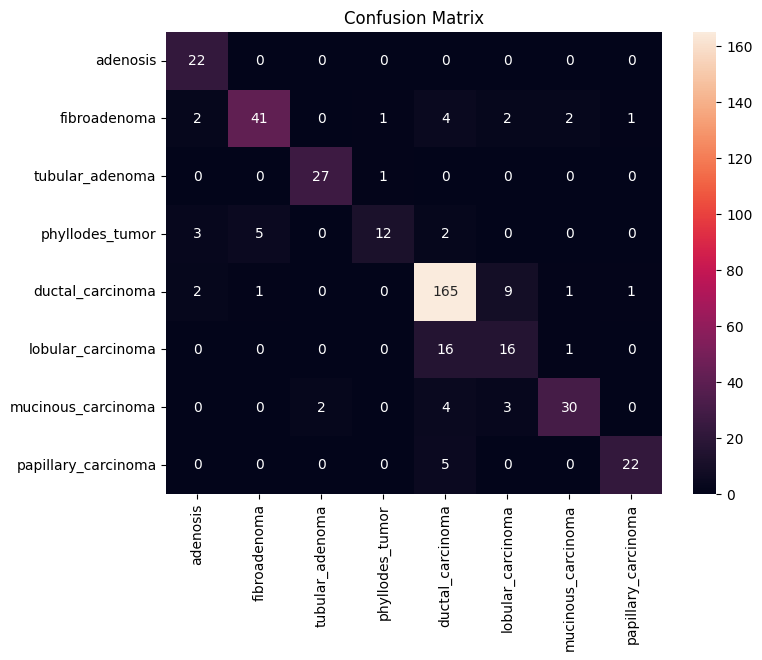

                     precision    recall  f1-score   support

           adenosis       0.76      1.00      0.86        22
       fibroadenoma       0.87      0.77      0.82        53
    tubular_adenoma       0.93      0.96      0.95        28
    phyllodes_tumor       0.86      0.55      0.67        22
   ductal_carcinoma       0.84      0.92      0.88       179
  lobular_carcinoma       0.53      0.48      0.51        33
 mucinous_carcinoma       0.88      0.77      0.82        39
papillary_carcinoma       0.92      0.81      0.86        27

           accuracy                           0.83       403
          macro avg       0.82      0.78      0.80       403
       weighted avg       0.83      0.83      0.83       403



In [17]:
# ==========================================================
# 14. EVALUATION
# ==========================================================
val_preds = model.predict(val_ds)
val_preds = np.argmax(val_preds, axis=1)

acc = accuracy_score(val_labels, val_preds)
print("Final Validation Accuracy:", acc)

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(val_labels, val_preds, target_names=CLASSES))

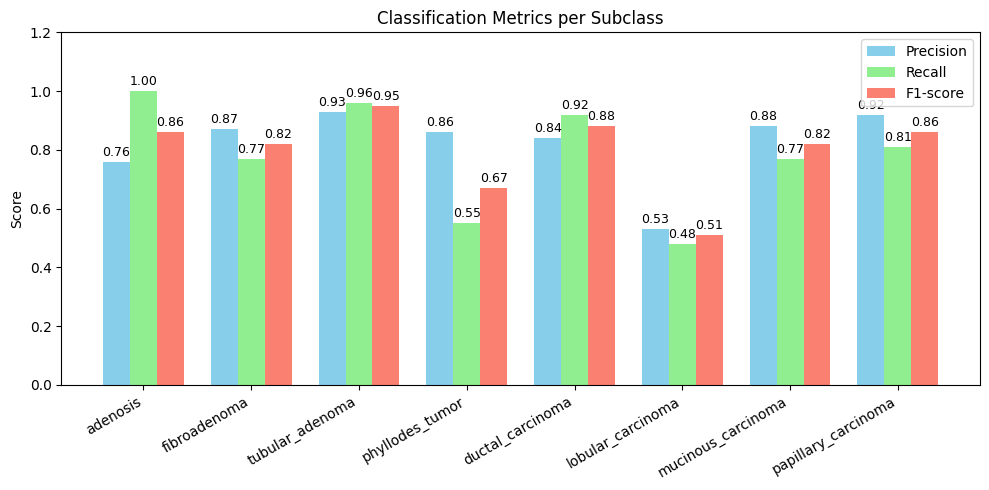

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Metrics per subclass
# -----------------------------
classes = [
    "adenosis", "fibroadenoma", "tubular_adenoma", "phyllodes_tumor",
    "ductal_carcinoma", "lobular_carcinoma", "mucinous_carcinoma", "papillary_carcinoma"
]

precision = [0.76, 0.87, 0.93, 0.86, 0.84, 0.53, 0.88, 0.92]
recall    = [1.00, 0.77, 0.96, 0.55, 0.92, 0.48, 0.77, 0.81]
f1_score  = [0.86, 0.82, 0.95, 0.67, 0.88, 0.51, 0.82, 0.86]

x = np.arange(len(classes))
width = 0.25  # width of each bar

plt.figure(figsize=(10,5))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1_score, width, label='F1-score', color='salmon')

plt.xticks(x, classes, rotation=30, ha='right')
plt.ylim(0, 1.2)
plt.ylabel("Score")
plt.title("Classification Metrics per Subclass")
plt.legend()

# Add value labels
for i in range(len(classes)):
    plt.text(i - width, precision[i] + 0.02, f"{precision[i]:.2f}", ha='center', fontsize=9)
    plt.text(i, recall[i] + 0.02, f"{recall[i]:.2f}", ha='center', fontsize=9)
    plt.text(i + width, f1_score[i] + 0.02, f"{f1_score[i]:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

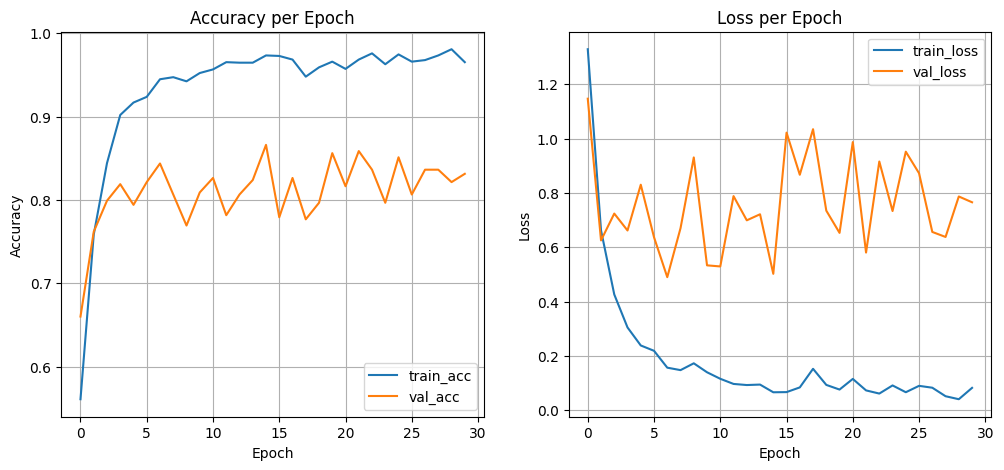

In [19]:
# ==========================================================
# 16. PLOT TRAINING & VALIDATION ACCURACY/LOSS
# ==========================================================
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy per Epoch")
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.grid()
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

# Get probability predictions
val_probs = model.predict(val_ds)
val_preds = np.argmax(val_probs, axis=1)

# Weighted F1 Score
weighted_f1 = f1_score(val_labels, val_preds, average='weighted')
print("Weighted F1-score:", weighted_f1)

# ROC-AUC per class (One-vs-Rest)
val_labels_bin = label_binarize(val_labels, classes=np.arange(len(CLASSES)))

roc_auc_per_class = {}

for i, cls in enumerate(CLASSES):
    try:
        auc = roc_auc_score(val_labels_bin[:, i], val_probs[:, i])
        roc_auc_per_class[cls] = auc
    except:
        roc_auc_per_class[cls] = None

print("\nROC-AUC per class:")
for k, v in roc_auc_per_class.items():
    print(f"{k}: {v}")


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
Weighted F1-score: 0.8269582916687707

ROC-AUC per class:
adenosis: 0.9998806967310904
fibroadenoma: 0.9773584905660377
tubular_adenoma: 0.9987619047619047
phyllodes_tumor: 0.9884275829157718
ductal_carcinoma: 0.9635998603351955
lobular_carcinoma: 0.9472153972153973
mucinous_carcinoma: 0.9527331642716258
papillary_carcinoma: 0.963849487785658


/tmp/ipykernel_55/3694571691.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=auc_values, palette="Reds_r")


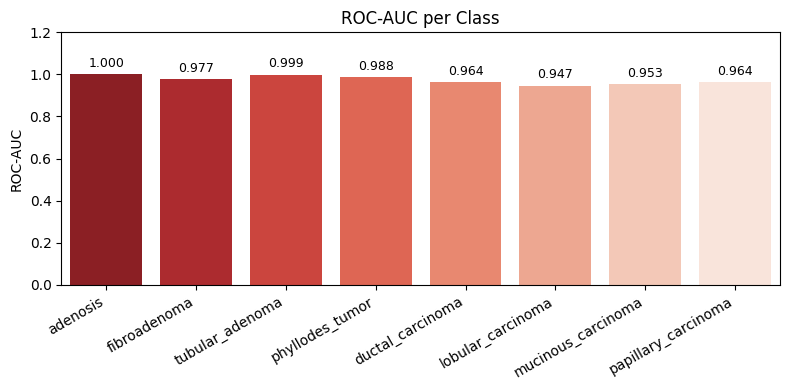

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# ROC-AUC per class (provided values)
# -----------------------------
classes = [
    "adenosis", "fibroadenoma", "tubular_adenoma", "phyllodes_tumor",
    "ductal_carcinoma", "lobular_carcinoma", "mucinous_carcinoma", "papillary_carcinoma"
]

auc_values = [
0.9998806967310904,
0.9773584905660377,
0.9987619047619047,
0.9884275829157718,
0.9635998603351955,
0.9472153972153973,
0.9527331642716258,
0.963849487785658

]

plt.figure(figsize=(8,4))
sns.barplot(x=classes, y=auc_values, palette="Reds_r")
plt.ylim(0, 1.2)  # extend y-axis for labels
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC per Class")
plt.xticks(rotation=30, ha="right")

# Add value labels on top of bars
for i, v in enumerate(auc_values):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step


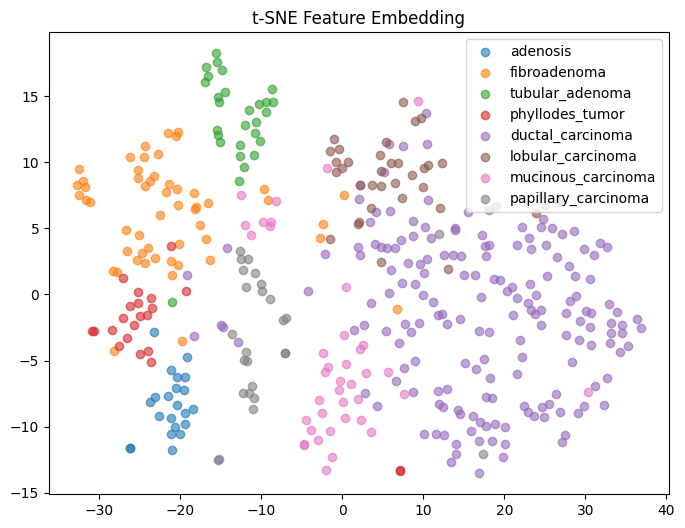

In [22]:
from sklearn.manifold import TSNE

# Create feature extractor (remove classifier head)
feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-3].output  # Dense(256) layer before Dropout
)

# Extract features
features = feature_extractor.predict(val_ds)
labels_for_tsne = val_labels

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
tsne_results = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(8,6))
for i in range(len(CLASSES)):
    idxs = labels_for_tsne == i
    plt.scatter(
        tsne_results[idxs, 0],
        tsne_results[idxs, 1],
        label=CLASSES[i],
        alpha=0.6
    )

plt.legend()
plt.title("t-SNE Feature Embedding")
plt.show()


26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


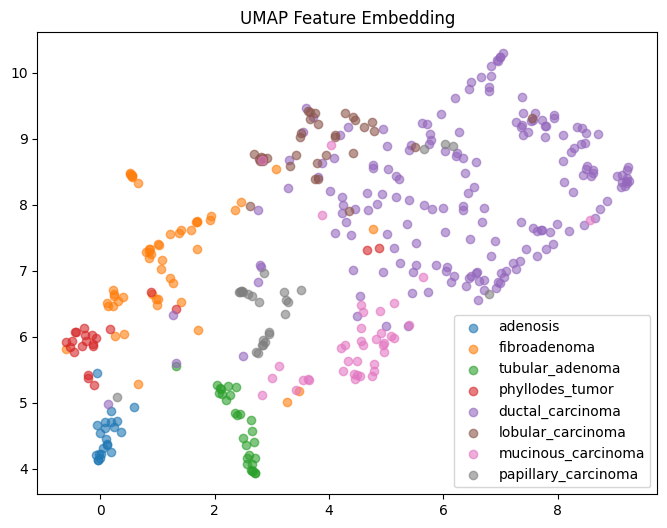

In [23]:
import umap

# Feature extractor same as before
features = feature_extractor.predict(val_ds)

# Apply UMAP
reducer = umap.UMAP(n_components=2, random_state=SEED)
umap_results = reducer.fit_transform(features)

plt.figure(figsize=(8,6))
for i in range(len(CLASSES)):
    idxs = val_labels == i
    plt.scatter(
        umap_results[idxs, 0],
        umap_results[idxs, 1],
        label=CLASSES[i],
        alpha=0.6
    )

plt.legend()
plt.title("UMAP Feature Embedding")
plt.show()


In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_labels, val_preds)

sensitivity = {}
specificity = {}

for i, cls in enumerate(CLASSES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    
    sensitivity[cls] = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity[cls] = TN / (TN + FP) if (TN + FP) > 0 else 0

print("Class-wise Sensitivity:")
for k,v in sensitivity.items():
    print(f"{k}: {v:.2f}")

print("\nClass-wise Specificity:")
for k,v in specificity.items():
    print(f"{k}: {v:.2f}")


Class-wise Sensitivity:
adenosis: 1.00
fibroadenoma: 0.77
tubular_adenoma: 0.96
phyllodes_tumor: 0.55
ductal_carcinoma: 0.92
lobular_carcinoma: 0.48
mucinous_carcinoma: 0.77
papillary_carcinoma: 0.81

Class-wise Specificity:
adenosis: 0.98
fibroadenoma: 0.98
tubular_adenoma: 0.99
phyllodes_tumor: 0.99
ductal_carcinoma: 0.86
lobular_carcinoma: 0.96
mucinous_carcinoma: 0.99
papillary_carcinoma: 0.99


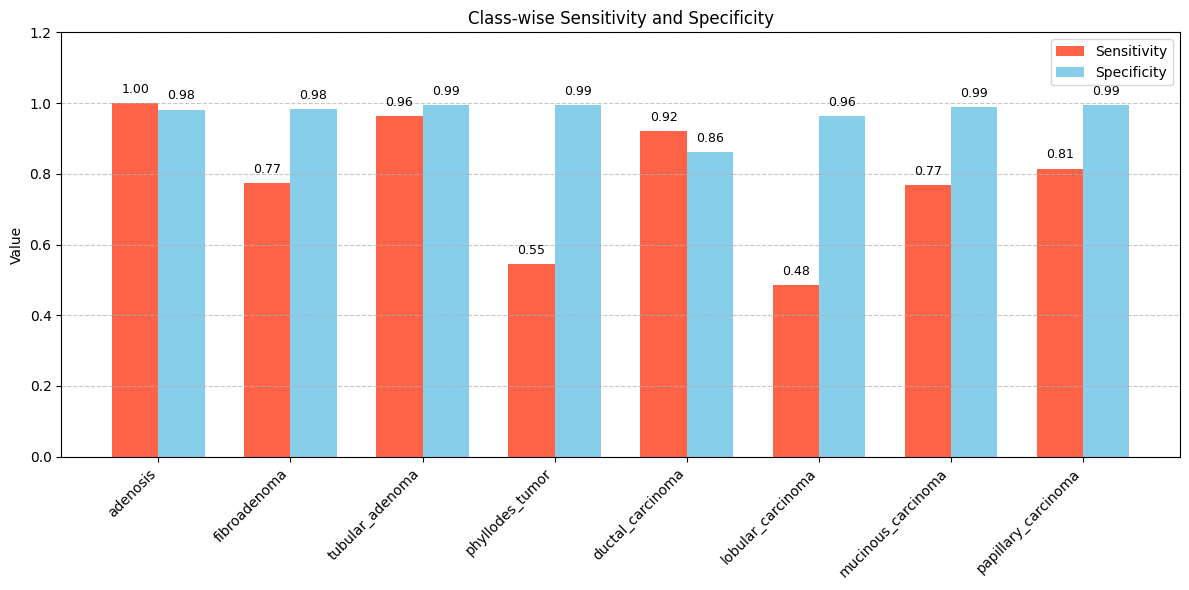

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Convert dictionaries to arrays for plotting
sens_values = [sensitivity[cls] for cls in CLASSES]
spec_values = [specificity[cls] for cls in CLASSES]

x = np.arange(len(CLASSES))  # class positions
width = 0.35  # width of bars

plt.figure(figsize=(12,6))
bars1 = plt.bar(x - width/2, sens_values, width, label='Sensitivity', color='tomato')
bars2 = plt.bar(x + width/2, spec_values, width, label='Specificity', color='skyblue')

plt.xticks(x, CLASSES, rotation=45, ha='right')
plt.ylabel("Value")
plt.ylim(0, 1.2)
plt.title("Class-wise Sensitivity and Specificity")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
